# Skyrmions on random pinning

GPU-accelerated 2D skyrmion dynamics simulator based on the overdamped Thiele equation,
implementing the model from [Reichhardt & Reichhardt, PRB 99, 104418 (2019)](https://link.aps.org/doi/10.1103/PhysRevB.99.104418).

## Physics

Each skyrmion obeys the Thiele equation:

$$ α·\mathbf{v} + \mathbf{G} \times \mathbf{v} = F^{ss}_{i} + F^{p}_{i} + F_{D}$$


where $α$ is the damping coefficient, $\mathbf{G} = G_z ẑ$ is the gyrovector, and the three forces are:

- $F^{ss}_{i}$ — skyrmion–skyrmion repulsion via modified Bessel K₁
- $F^{p}_{i}$ — parabolic potential wells placed at random (or from file)
- $F_{D}$ — uniform applied drive with tunable magnitude and direction


---

## Building

1. On the HPC cluster, run the script `build.sh` to compile the program. In the script, modify the loaded modules if necessary:
```bash
module load gcc/8.2.0
module load cuda/11.4.0
module load cmake-3.19.2-gcc-8.2.0
```

```bash
bash build.sh # load modules, cleans, configures, and compiles in Release mode
```

2. To build manually with custom CUDA architecture:

```bash
mkdir build && cd build
cmake .. -DCMAKE_BUILD_TYPE=Release -DCMAKE_CUDA_ARCHITECTURES=86
make -j$(nproc)
```

CMake options:

| Flag | Default | Description |
|---|---|---|
| `CMAKE_CUDA_ARCHITECTURES` | `70;75;80;86` | GPU SM targets |
| `SK_FLOAT` | `ON` | Single-precision GPU arithmetic (faster); `OFF` for double |

The binary is written to `build/skyrmion_sim`.



---

## Usage

```bash
./build/skyrmion_sim <config.conf>
```

The simulator reads all parameters from the config file and writes four output files to `output_dir/`.

### Example

```bash
./build/skyrmion_sim inputs/example.conf
```

---

## Configuration

Config files use an INI-style format. Lines beginning with `#` or `;` are comments.
Keys are case-insensitive; only keys you want to override need to appear
(all parameters have sensible defaults). See [inputs/example.conf](inputs/example.conf) for the full reference.

### Key sections

**`[system]`** — lattice geometry

| Key | Description |
|---|---|
| `nx`, `ny` | Grid of skyrmions; total `N = nx × ny` |
| `n_sk` | Skyrmion density → lattice constant `a = sqrt(sqrt(3)/(2·n_sk))` |
| `pbc` | Periodic boundary conditions (`true`/`false`) |

**`[thiele]`** — equation of motion

| Key | Description |
|---|---|
| `alpha` | Damping coefficient αD |
| `g_z` | Gyrovector z-component; Hall angle `k = g_z/alpha` |

**`[skyrmion_skyrmion]`** — inter-skyrmion repulsion

| Key | Description |
|---|---|
| `K1` | Interaction prefactor |
| `lambda` | Interaction range (in units of `a₀`) |

**`[pinning]`** — disorder

| Key | Description |
|---|---|
| `n_p` | Pin density (pins per unit area); `N_pins = round(n_p · Lx · Ly)` |
| `f_p` | Maximum pin force magnitude |
| `r_p` | Pin capture radius (in units of `a₀`) |
| `pin_file` | *(optional)* Path to a file with explicit pin positions |

**`[drive]`** — applied force

| Key | Description |
|---|---|
| `F_D` | Drive magnitude |
| `drive_angle` | Drive direction in degrees (0 = +x) |

**`[integration]`**

| Key | Description |
|---|---|
| `integrator` | `euler` or `rk2` |
| `dt` | Time step |
| `t_max` | Total simulation time |

**`[init]`** — initial positions

| Key | Description |
|---|---|
| `init_layout` | `triangular` (perfect lattice), `random`, or `file` |
| `seed` | RNG seed |
| `init_file` | Path to positions file when `init_layout = file` |

**`[output]`**

| Key | Description |
|---|---|
| `output_dir` | Directory for output files (created if absent) |
| `run_tag` | Prefix for all output filenames |
| `save_every` | Steps between trajectory snapshots |
| `thermo_every` | Steps between scalar diagnostics |
| `save_vel` | Also write velocities in the trajectory file (`true`/`false`) |

**`[misc]`**

| Key | Description |
|---|---|
| `n_threads` | CUDA threads per block (default 256) |
| `verbose` | Print timing and progress to stdout |
| `use_pin_cells` | Use cell-linked list for O(N) pin search (recommended for large N) |

---

## Output files

All files are written to `output_dir/` with the prefix `run_tag`.

### `{run_tag}_traj.dat` — position snapshots

```
# Skyrmion trajectory
# N=256  Lx=37.2  Ly=32.2  alpha=1.0  G_z=0.79
# Columns: i  x  y
# (each block: step=<s> t=<t>)
# step=0 t=0.000000e+00
0  1.234  5.678
1  2.345  6.789
...
```

A block is written every `save_every` steps. If `save_vel = true`, columns `vx vy` are appended.
Positions are in unfolded (unwrapped) coordinates; PBC applies via minimum-image in force calculations.

### `{run_tag}_thermo.dat` — scalar time series

```
# step  t  vx_mean  vy_mean  vmag_mean
0  0.00e+00  2.47e-03  -1.91e-03  3.12e-03
100  1.00e+01  ...
```

One row every `thermo_every` steps: mean velocity components and magnitude averaged over all skyrmions.

### `{run_tag}_summary.dat` — end-of-run summary

Key–value file written once at the end. Contains all physical parameters plus time-averaged velocities
computed over the **last 50%** of thermo samples (steady-state estimate):

```
vx_avg        2.47e-03
vy_avg        -1.91e-03
vmag_avg      3.12e-03
theta_H_deg   -37.7
```

`theta_H_deg` is the Hall angle of the mean velocity vector.

### `{run_tag}_pins.dat` — pin positions

```
# Pin positions  N_pins=512  r_p=0.5
# Columns: i  px  py
0  384.52  512.30
...
```

Written once at the start of the run. Useful for reproducing or visualising the disorder configuration.

---

## Parameter sweeps

The [scripts/run_sweep.sh](scripts/run_sweep.sh) script loops over a range of `F_D` values,
patching the base config via `sed` for each point:

```bash
bash scripts/run_sweep.sh
```

Results land in `results/depinning/`, one set of four output files per `F_D` value.

---

## Analysis scripts

All scripts live in [scripts/](scripts/) and expect data in the standard output format above.

| Script | Purpose |
|---|---|
| `plot_step.py` | Slider: skyrmion trajectories over steps. |
| `plot_depinning.py` | Plot <vx> vs FD (results from `run_sweep.sh`) |


---

## Code structure

```
skyrmion_sim/
├── src/
│   ├── main.cu          entry point — parse config, call simulation::run()
│   ├── simulation.cu    main loop, state init, output scheduling
│   ├── forces.cu        F_ss, F_pin, F_D kernels; Thiele velocity solver
│   ├── integrators.cu   Euler and RK2 step kernels
│   ├── io.cpp           ASCII output (traj, thermo, summary, pins)
│   ├── params.cpp       INI config parser
│   └── rng.cu           cuRAND wrapper
├── include/             matching headers + state.h, precision.h
├── inputs/              example .conf files
├── scripts/             Python plots and sweep scripts
└── build.sh             one-shot build helper
```

## Getting started

Clone the repository and enter the project directory:

```bash
git clone git@github.com:fabripusiol95/skyrmion_sim.git
cd skyrmion_sim
```

**Prerequisites:** a CUDA-capable GPU, CUDA ≥ 11, GCC ≥ 8, and CMake ≥ 3.19.
On an HPC cluster these are typically available as environment modules (see [Building](#Building)).

From the repository root, build the simulator with:

In [ ]:
!mkdir -p build && cd build && cmake .. -DCMAKE_BUILD_TYPE=Release -DCMAKE_CUDA_ARCHITECTURES=75 && make -j$(nproc)

## Example

`inputs/example.conf` is a configuration file with parameters taken from [Reichhardt & Reichhardt, PRB 99, 104418 (2019)](https://link.aps.org/doi/10.1103/PhysRevB.99.104418).

In [2]:
!cat inputs/example.conf

# ─────────────────────────────────────────────────────────────────────────────
#  Skyrmion simulation — example parameter file. Values extracted from Fig. 1 of:
#  Reichhardt 2019, PRB 99, 104418
#
#  Lines starting with '#' or ';' are comments.
#  Keys are case-insensitive.  Only keys you want to override need to appear.
# ─────────────────────────────────────────────────────────────────────────────

[system]
nx          = 16           # skyrmions along x  (N = nx*ny)
ny          = 16          # skyrmions along y
n_sk        = 0.16          # skyrmion density → a = sqrt(sqrt(3)/(2*n_sk)), Lx = a*nx, Ly = (sqrt(3)/2)*a*ny
pbc         = true         # periodic boundary conditions

[thiele]
alpha       = 1.0          # damping coefficient α_D
g_z         = 0.791795842  # gyrovector z-component  →  Hall angle k = g_z/alpha

[skyrmion_skyrmion]
K1          = 1.0          # interaction prefactor
lambda      = 1.0          # interaction range (a_0 units)

[pinning]
n_p         = 0.2       #

Run the simulation with:

In [ ]:
!./build/skyrmion_sim inputs/example.conf

Results were written to `results/example`:

In [5]:
!ls results/example/ && echo '' && head -n 15 results/example/*.dat

test_pins.dat  test_summary.dat  test_thermo.dat  test_traj.dat

==> results/example/test_pins.dat <==
# Pin positions  N_pins=240  r_p=0.5
# Columns: i  px  py
0 2.4032503128e+01 3.2018661499e+01
1 2.1550903320e+01 1.1915571213e+01
2 9.2473363876e+00 6.7772669792e+00
3 1.7935794830e+01 3.0376171112e+01
4 9.6698331833e+00 3.1882907867e+01
5 3.3669212341e+01 9.0689535141e+00
6 3.3835971832e+01 3.7586829662e+00
7 2.9507040024e+01 2.2814649582e+01
8 3.1782598495e+01 2.6802963257e+01
9 2.7190824509e+01 2.2977466583e+01
10 9.6710691452e+00 1.0163487434e+01
11 1.3176827431e+01 4.1872377396e+00
12 3.3304367065e+01 1.1267319679e+01

==> results/example/test_summary.dat <==
# Skyrmion simulation summary — test
# Velocities averaged over the last 50% of thermo samples
nx            16
ny            16
N             256
n_sk          1.60000000e-01
Lx            3.72241944e+01
Ly            3.22370980e+01
alpha         1.00000000e+00
G_z           7.91795842e-01
K1            1.00000000e+00
lambd

Plot skyrmion positions using the `plot_step` function:

In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def plot_step(dirdata, runtag, step):
    dir_data = dirdata
    basename = runtag

    traj_path = os.path.join(dir_data, f'{basename}_traj.dat')
    with open(traj_path) as f:
        f.readline()  # skip first comment line
        params_line = f.readline().strip().lstrip('#').strip()
    params = dict(kv.split('=') for kv in params_line.split())
    Lx, Ly = float(params['Lx']), float(params['Ly'])
    N = int(params['N'])

    # Parse all steps from trajectory file
    steps = []      # list of dicts: {step, t, pos}
    step_re = re.compile(r'#\s*step=(\d+)\s+t=([\deE+\-.]+)')

    with open(traj_path) as f:
        current_meta = None
        current_rows = []
        for line in f:
            line = line.rstrip('\n')
            m = step_re.search(line)
            if m:
                if current_meta is not None and len(current_rows) == N:
                    steps.append({**current_meta, 'pos': np.array(current_rows)})
                current_meta = {'step': int(m.group(1)), 't': float(m.group(2))}
                current_rows = []
            elif line.startswith('#') or line.strip() == '':
                continue
            else:
                current_rows.append([float(v) for v in line.split()])
        if current_meta is not None and len(current_rows) == N:
            steps.append({**current_meta, 'pos': np.array(current_rows)})

    n_steps = len(steps)

    pins_path = os.path.join(dir_data, f'{basename}_pins.dat')
    pin = np.loadtxt(pins_path, comments='#', skiprows=0) if os.path.exists(pins_path) else None

    fig, ax = plt.subplots(figsize=(6, 6))
    fig.subplots_adjust(bottom=0.12)

    if pin is not None:
        ax.plot(pin[:, 1], pin[:, 2], 'o',
                color='grey',
                markersize=3,
                alpha=0.5,
                label='Pinning sites')
        for px, py in zip(pin[:, 1], pin[:, 2]):
            ax.add_patch(plt.Circle((px, py), 0.5,
                                    color='grey',
                                    fill=True,
                                    alpha=0.1,
                                    linewidth=0.5))
    ax.add_patch(plt.Rectangle((0, 0), Lx, Ly, linewidth=1.75, edgecolor='black', facecolor='none'))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(-Lx*0.05, Lx + Lx*0.05)
    ax.set_ylim(-Ly*0.05, Ly + Ly*0.05)
    ax.set_aspect(1)

    pos0 = steps[int(step)]['pos']
    scat = ax.plot(pos0[:, 1] % Lx, pos0[:, 2] % Ly, 'o',
                color='xkcd:dark red', 
                markersize=7,
                markeredgecolor='gray',
                markeredgewidth=0.5,
                label='Skyrmions')[0]
    title = ax.set_title(f"file: {str(basename)} \nstep={steps[int(step)]['step']}  t={steps[int(step)]['t']:.3e} ")
    ax.legend(loc='upper left', bbox_to_anchor=(-0.1, 1.2))
    plt.show()

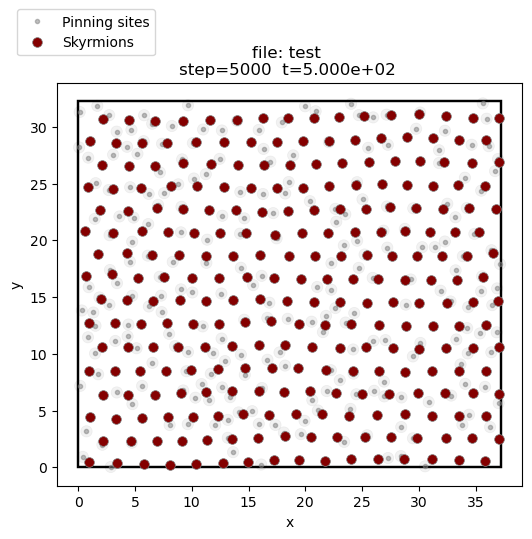

In [ ]:
plot_step('results/example', 'test', step=100) # modify step number to plot different steps

Plot the mean velocity components as a function of time:

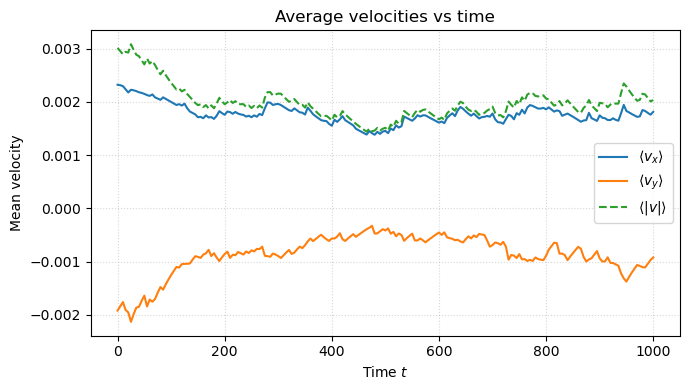

In [18]:
thermo_path = 'results/example/test_thermo.dat'

data = np.loadtxt(thermo_path, comments='#')
t       = data[:, 1]
vx_mean = data[:, 2]
vy_mean = data[:, 3]
vmag    = data[:, 4]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, vx_mean, label=r'$\langle v_x \rangle$')
ax.plot(t, vy_mean, label=r'$\langle v_y \rangle$')
ax.plot(t, vmag,    label=r'$\langle |v| \rangle$', linestyle='--')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Mean velocity')
ax.set_title('Average velocities vs time')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Run Sweep

For a study of the depinning field, execute the script `run_sweep.sh`. This script sweeps values of $F_{D} = 0, 0.0005, \dots, 0.01$. Results are saved in `results/depinning`.

In [ ]:
!bash scripts/run_sweep.sh

#!/usr/bin/env bash
set -euo pipefail

EXECUTABLE="./build/skyrmion_sim"
BASE_CONF="inputs/depinning_test.conf"
TMP_CONF=$(mktemp /tmp/skyrmion_XXXXXX.conf)

trap 'rm -f "$TMP_CONF"' EXIT

mkdir -p ../results/depinning

for FD in $(seq -f "%.4f" 0 0.0005 0.01); do
    TAG="Force_F_D_${FD}"
    echo "Running F_D = ${FD}  →  run_tag = ${TAG}"

    sed \
        -e "s|^F_D\s*=.*|F_D         = ${FD}|" \
        -e "s|^output_dir\s*=.*|output_dir  = results/depinning|" \
        -e "s|^run_tag\s*=.*|run_tag     = ${TAG}|" \
        "$BASE_CONF" > "$TMP_CONF"

    "$EXECUTABLE" "$TMP_CONF"
done

echo "All runs complete. Results in results/depinning/"


In [22]:
!ls results/depinning/

Force_F_D_0.0000_pins.dat     Force_F_D_0.0050_thermo.dat
Force_F_D_0.0000_summary.dat  Force_F_D_0.0050_traj.dat
Force_F_D_0.0000_thermo.dat   Force_F_D_0.0055_pins.dat
Force_F_D_0.0000_traj.dat     Force_F_D_0.0055_summary.dat
Force_F_D_0.0005_pins.dat     Force_F_D_0.0055_thermo.dat
Force_F_D_0.0005_summary.dat  Force_F_D_0.0055_traj.dat
Force_F_D_0.0005_thermo.dat   Force_F_D_0.0060_pins.dat
Force_F_D_0.0005_traj.dat     Force_F_D_0.0060_summary.dat
Force_F_D_0.0010_pins.dat     Force_F_D_0.0060_thermo.dat
Force_F_D_0.0010_summary.dat  Force_F_D_0.0060_traj.dat
Force_F_D_0.0010_thermo.dat   Force_F_D_0.0065_pins.dat
Force_F_D_0.0010_traj.dat     Force_F_D_0.0065_summary.dat
Force_F_D_0.0015_pins.dat     Force_F_D_0.0065_thermo.dat
Force_F_D_0.0015_summary.dat  Force_F_D_0.0065_traj.dat
Force_F_D_0.0015_thermo.dat   Force_F_D_0.0070_pins.dat
Force_F_D_0.0015_traj.dat     Force_F_D_0.0070_summary.dat
Force_F_D_0.0020_pins.dat     Force_F_D_0.0070_thermo.dat
Force_F_D_0.0020_summary.d

## Depinning curve: $\langle v_x \rangle$ vs $F_D$

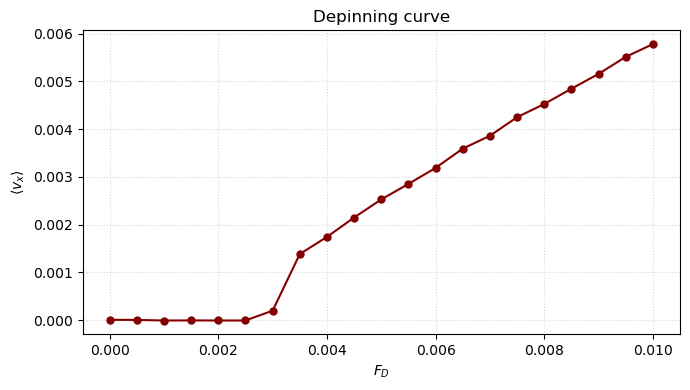

In [23]:
import glob, re
import numpy as np
import matplotlib.pyplot as plt

def parse_summary(path):
    kv = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
            parts = line.split()
            if len(parts) == 2:
                kv[parts[0]] = float(parts[1])
    return kv

summary_files = sorted(glob.glob('results/depinning/Force_F_D_*_summary.dat'))

FD_vals, vx_vals = [], []
for path in summary_files:
    d = parse_summary(path)
    FD_vals.append(d['F_D'])
    vx_vals.append(d['vx_avg'])

FD_vals = np.array(FD_vals)
vx_vals = np.array(vx_vals)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(FD_vals, vx_vals, 'o-', color='xkcd:dark red', markersize=5, linewidth=1.5)
ax.set_xlabel(r'$F_D$')
ax.set_ylabel(r'$\langle v_x \rangle$')
ax.set_title('Depinning curve')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()